<a href="https://colab.research.google.com/github/alaycheme25/chemeng277_batteryproject/blob/main/Regularization_with_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import json
import pandas as pd
from sklearn.metrics import roc_curve, auc, r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast


ModuleNotFoundError: No module named 'paretoset'

In [2]:
# Importing the new_data files from Materials Project and merging with another dataset on material cost
pdata = pd.read_excel('mp_battery_data_new.csv.xlsx')
pdata2 = pd.read_excel('mp_battery_data_new2.xlsx') #energy density calculation
pdata2["energy_density"] = pdata2["capacity_grav"] / pdata2["capacity_vol"] #units: kWh/L
pdata2.to_csv("mp_battery_data_new2.csv", index=False)

cost_df = pd.read_excel('working_ion_cost_per_kWh.xlsx') #dataset on material cost
pdata3 = pdata2.merge (cost_df[["Working Ion", "Average Cost Contribution ($/kWh)"]],
    left_on="working_ion",
    right_on="Working Ion",
    how="left"
)
# Rename the new column
pdata3 = pdata3.rename(columns={"Average Cost Contribution ($/kWh)": "working_ion_cost_per_kWh"})
# Remove duplicate join column
pdata3 = pdata3.drop(columns=["Working Ion"])
# Save updated spreadsheet
pdata3.to_csv("mp_battery_data_new2_with_cost.csv", index=False)
#Multiply cost/kWh by energy density to get cost/L of battery volume
pdata3["battery_volume_cost"] = pdata3["energy_density"] * pdata3["working_ion_cost_per_kWh"] #units: cost/L of battery volume
pdata3.to_csv("mp_battery_data_new2_with_cost.csv", index=False)


NameError: name 'pd' is not defined

In [ ]:
# Trimming the data:
index = np.where("fields_not_requested_y" == np.array(pdata.columns.tolist()))[0][0]
pdata = pdata.iloc[:, 2:index]
pdata.drop(columns=["fields_not_requested_x", "host_structure", "material_id", "id_charge","id_discharge"], axis=1, inplace=True)
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,structure,formation_energy_per_atom,band_gap
0,Li0-3Ce,Li,['Ce'],1,Ce,Li3Ce,2.951183,-0.444846,499.595769,-222.242937,0,0.333634,2.592432,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0
1,Li0-3Sb,Li,['Sb'],1,Sb,Li3Sb,1.569237,1.015953,563.913254,572.909146,0.328351,0,3.378028,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074
2,Li0-0.17C,Li,['C'],1,C,LiC6,0.025414,0.084405,339.236925,28.633212,0.011936,0.002406,2.237712,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0
3,Li4.25-4.4Sn,Li,['Sn'],1,Li17Sn4,Li22Sn5,0.00945,-0.362516,26.93609,-9.764758,0,0.01007,2.583328,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0
4,Li0-1Bi,Li,['Bi'],1,Bi,LiBi,0.368255,0.796796,124.126099,98.903144,0.049545,0,7.527518,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0


#### [NEW] Unpacking the structure column

In [ ]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [ ]:
def get_volume(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.volume
    except:
        return np.nan
structure_volums = pdata["structure"].apply(get_volume) # Volumes in Angstrom^3
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)

           a          b          c
0   5.263072   5.263072   5.263072
1   4.627959   4.627959   4.627959
2   3.649504   4.306932   4.306932
3  13.947939  13.947939  13.947939
4   3.320590   3.320590   4.319788


In [ ]:
# Finding rows with Nan values in structure_volums and replacing them with 0
structure_volums = structure_volums.to_frame()
structure_volums = structure_volums.fillna(0)
structure_volums = structure_volums["structure"]
print(structure_volums.shape)
print(structure_abc_df.shape)

(5786,)
(5786, 3)


#### Back to data processing:

In [ ]:
# Getting the fittable data for given elements
fitdata = pdata.iloc[:, 6:]
rows_with_strings = []

# Check if there are any strings in the data
for i in range(1, len(fitdata.columns)):
    for j in range(len(fitdata)):
        if type(fitdata.iloc[j, i]) == str or fitdata.iloc[j, i] == "None" or fitdata.iloc[j, i] == "none" or np.isnan(fitdata.iloc[j, i]):
            rows_with_strings.append(j)
pdata = pdata.drop(rows_with_strings, inplace=False)
fitdata = fitdata.drop(rows_with_strings, inplace=False)
structure_volums = structure_volums.drop(rows_with_strings, inplace=False)
structure_abc_df = structure_abc_df.drop(rows_with_strings, inplace=False)
print(structure_abc_df.shape)
print(structure_volums.shape)
pdata["elements"] = pdata["elements"].apply(lambda x: x.replace("[", "").replace("]", "").replace(" ", "").replace("'", ""))
pdata.head()

(5778, 3)
(5778,)


,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,formation_energy_per_atom,band_gap
0,Li0-3Ce,Li,Ce,1,Ce,Li3Ce,2.951183,-0.444846,499.595769,-222.242937,0,0.333634,2.592432,0.333634,0
1,Li0-3Sb,Li,Sb,1,Sb,Li3Sb,1.569237,1.015953,563.913254,572.909146,0.328351,0,3.378028,-0.744135,0.7074
2,Li0-0.17C,Li,C,1,C,LiC6,0.025414,0.084405,339.236925,28.633212,0.011936,0.002406,2.237712,-0.034716,0
3,Li4.25-4.4Sn,Li,Sn,1,Li17Sn4,Li22Sn5,0.00945,-0.362516,26.93609,-9.764758,0,0.01007,2.583328,-0.330999,0
4,Li0-1Bi,Li,Bi,1,Bi,LiBi,0.368255,0.796796,124.126099,98.903144,0.049545,0,7.527518,-0.415156,0


In [ ]:
# Centering the data
for i in range(0, len(fitdata.columns)):
    fitdata.iloc[:, i] -=  np.nanmean(fitdata.iloc[:, i])
fitdata = fitdata.fillna(0)
fitdata = fitdata.astype(float)


C:\Users\allen\AppData\Local\Temp\ipykernel_7808\3130102122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fitdata = fitdata.fillna(0)


In [ ]:
fitdata.head()

,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,formation_energy_per_atom,band_gap
0,2.601190,-3.075212,351.571799,-583.375288,-0.108948,0.207375,-1.441571,2.498688,-1.139843
1,1.219244,-1.614414,415.889284,211.776794,0.219403,-0.126259,-0.655975,1.420918,-0.432443
2,-0.324579,-2.545962,191.212956,-332.499139,-0.097012,-0.123853,-1.796291,2.130337,-1.139843
3,-0.340543,-2.992883,-121.087880,-370.897110,-0.108948,-0.116189,-1.450676,1.834055,-1.139843
4,0.018262,-1.833571,-23.897871,-262.229208,-0.059403,-0.126259,3.493515,1.749897,-1.139843


### Performing the PCA Algorithm

In [ ]:
# Change n_components if you want to reduce the dimensionality of the data. The default is to keep all components. Feel free to change any parameters of PCA as you see fit!
n_components = len(fitdata.columns)
pca = PCA(n_components=n_components)
pca.fit(fitdata)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

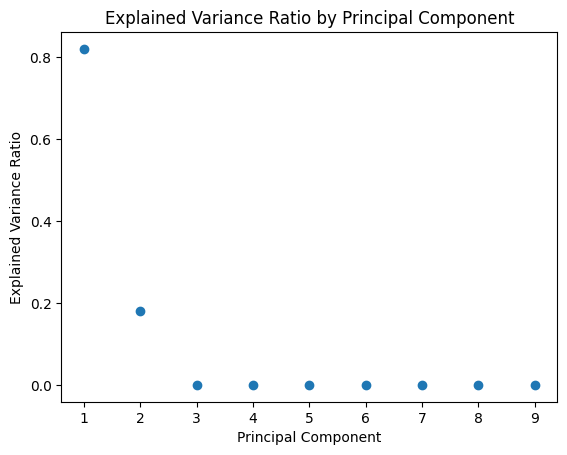

In [ ]:
lambdas = pca.explained_variance_ratio_
plt.scatter(range(1, len(lambdas) + 1), lambdas)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.show()

#### Uncomment and run the following cell to project data onto chosen number of principal components:

In [ ]:
#pca_data = pca.transform(fitdata)

#### Running ridge regression on the full dataset (fit data + element labels)
Ideally, datasets are broken up into different working electrolytes/element compounds, then modeled appropriately.
Then choose the most optimal combination given the molecule and see if it has any global maximuma for any tuning parameter.

In [ ]:
scaler = MinMaxScaler() # introducing a normalizing factor for the data as opposed to centralising, for the paretoset.
# The model still uses centred data and hence has numerical stability
pdata_norm = pdata.iloc[:, 6:]
pdata_norm = fitdata.astype(float)
pdata_norm = pd.DataFrame(
    scaler.fit_transform(pdata_norm),
    columns=pdata_norm.columns,
    index=pdata_norm.index
)

In [ ]:
front_index = paretoset.paretoset(pdata_norm, sense=["min", "max", "max", "min", "min", "min", "min", "min", "min"])
# Voltage and capacity alone are to be maximized - band gap, density and even voltage are vague measurements and depend on the application.
# A heavy duty battery for application like automobile battery is considered.
fitdata = fitdata.iloc[front_index]
pdata_front = pdata.iloc[front_index]
structure_volums = structure_volums.iloc[front_index]
structure_abc_df = structure_abc_df.iloc[front_index]

In [ ]:
pdata.shape # Checking if pareto set removed significant share of data

(5584, 15)

In [ ]:
# Get all elements in working_ion and elements columns from pdata
working_ion_mass = pdata_front["working_ion"].apply(lambda x: periodictable.elements.symbol(x).mass)
elements_mass = pdata_front["elements"].apply(lambda x: sum([periodictable.elements.symbol(el).mass for el in x.split(",")]))

#### NEW MODEL: Capacity-based scoring

Gravimetric capacity is taken as the most important parameter for ranking a battery.

#### Implementing the scoring function
Assign labels/Scoring Method- for features: valuable features, grav_capacity, delta_v (for effective cost given density), working ion, elements, nelements, structure, chemical family*


Chemical family is a little difficult to get since it's not on the materials project dataset, but if we first generate the top 100 best materials and cross check with the other dataset, we can include that in our model manually.

In [ ]:
def scoring(capacity_g, avg_v, working_ion, elements, nelements, structure_v, abc):
    a = abc["a"]
    b = abc["b"]
    c = abc["c"]
    score = capacity_g * 0.4 + avg_v * 0.4 + working_ion * 1 - elements * 0.05 + nelements * 0.1 - structure_v * 0.05 + a + b + c  #+ chemical_family * 0.05
    return score

In [ ]:
#battery_score = working_ion_mass + elements_mass*pdata["nelements"]
battery_score = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_mass, elements_mass, pdata_front["nelements"], structure_volums,structure_abc_df)
print(structure_abc_df)
# Testing to see if the model works with a randomly generated sample of fitdata and battery score
fit_train, fit_test, score_train, score_test = train_test_split(fitdata, battery_score, test_size=0.1, random_state=42)

              a          b          c
0      5.263072   5.263072   5.263072
1      4.627959   4.627959   4.627959
2      3.649504   4.306932   4.306932
3     13.947939  13.947939  13.947939
4      3.320590   3.320590   4.319788
...         ...        ...        ...
5781  15.448884  15.448884  15.448884
5782   4.908004   8.150276   7.194592
5783   3.637375   8.494516  10.085012
5784   7.242778   7.242932   7.136566
5785   6.075697   6.075367  15.221762

[5584 rows x 3 columns]


In [ ]:
ridge = linear_model.Ridge(alpha=1.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(score_pred)

0.9630554349538852


In [ ]:
best = np.where(battery_score == np.max(battery_score))[0][0]  #np.min(battery_score) was changed to max(battery_score) to obtain best capacity
print(pdata.iloc[best, 0:12])

battery_formula            Mg0-3C
working_ion                    Mg
elements                        C
nelements                       1
formula_charge                  C
formula_discharge            Mg3C
max_delta_volume        12.458089
average_voltage          0.003174
capacity_grav          1893.52442
energy_grav              6.009535
stability_charge         2.756673
stability_discharge      0.684408
Name: 264, dtype: object


In [ ]:

X = fitdata
y = scoring(fitdata["capacity_grav"], fitdata["average_voltage"], working_ion_mass, elements_mass, pdata_front["nelements"], structure_volums, structure_abc_df)
y = y.fillna(0)
y = y.astype(float)

C:\Users\allen\AppData\Local\Temp\ipykernel_7808\1728413933.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.fillna(0)


In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=1.0))
])

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #Find best material in predicted set
    bestmaterial.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
print("Best materials in each fold:", type(bestmaterial[0]))
bestmaterial_df = pd.DataFrame(bestmaterial)

Mean R2: 0.9475673073186242
Mean MSE: 231.9539379253353
Mean MAE: 11.297050655798275
Best materials in each fold: <class 'pandas.core.series.Series'>


In [ ]:
# Finding the equivalent material in the original pdata for each best material in bestmaterial_df by minimizing the difference between each feature of bestmaterial_df and pdata
for i in range(len(bestmaterial)):
    best_material = bestmaterial_df.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Mg7-149Cs
Best material in fold 2:
Mg0-3C
Best material in fold 3:
Mg0-3C
Best material in fold 4:
Mg0-7V
Best material in fold 5:
Mg7-149Cs
